- NUR ALISHA BALQIS BINTI MOHD SUKRI (S67494)
- NUR ADIBAH HANUM BINTI MOHD FAUZI (S65581)
- NOOR SHAHIERA ILYANA BINTI KHAIRUL ANUAR (S67538)
- AEISYATUL MURSYIDA BINTI MOHD NOOR (S66792)
- SITI NUR AMANI BINTI MOHD AZMIN (S66170)

## INTRODUCTION

The "Stroke Prediction Dataset" can be found on Kaggle, and is sourced from a study that collected data on patients who have had a stroke. The dataset includes information on patient demographics, lifestyle factors, and medical history. The goal of the study is to predict the likelihood of a patient having a stroke.
The dataset includes the following attributes:
  - id: a unique identifier for each patient
  - gender: the patient's gender (male or female)
  - age: the patient's age
  - hypertension: whether the patient has hypertension (high blood pressure)
  - heart_disease: whether the patient has heart disease
  - ever_married: whether the patient has ever been married
  - work_type: the patient's employment status
  - Residence_type: the patient's residence type
  - avg_glucose_level: the patient's average glucose level
  - bmi: the patient's body mass index
  - smoking_status: the patient's smoking status
  - stroke: whether the patient has had a stroke (the target variable)

The dataset includes 5110 observations, and all the attributes are of categorical type except for the 'age' and 'avg_glucose_level' which are numerical.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly

In [4]:
stroke = pd.read_csv("stroke_data.csv")
stroke

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [5]:
stroke = stroke.drop('id', axis=1)

- Column 'id' is drop as it is not a factor of getting stroke

In [6]:
type(stroke)

pandas.core.frame.DataFrame

In [7]:
stroke.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


- There is no null value in stroke prediction dataset

In [8]:
stroke.isnull().sum().sort_values(ascending = False)

bmi                  201
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
smoking_status         0
stroke                 0
dtype: int64

- There are 201 missing values in the dataset

In [9]:
stroke['bmi'].value_counts()

28.7    41
28.4    38
26.7    37
27.6    37
26.1    37
        ..
48.7     1
49.2     1
51.0     1
49.4     1
14.9     1
Name: bmi, Length: 418, dtype: int64

In [10]:
stroke['bmi'].describe()

count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

In [11]:
stroke['bmi'].fillna(stroke['bmi'].mean(),inplace=True)
stroke['bmi'].describe()

count    5110.000000
mean       28.893237
std         7.698018
min        10.300000
25%        23.800000
50%        28.400000
75%        32.800000
max        97.600000
Name: bmi, dtype: float64

- Use fillna() method to replace the null values with a specified value.

In [12]:
stroke.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [13]:
stroke.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.698018,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.800000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.400000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,32.800000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


- Getting statistics of stroke data

In [14]:
stroke["stroke"].value_counts()

0    4861
1     249
Name: stroke, dtype: int64

In [15]:
percentage_stroke = ((stroke["stroke"].value_counts(0))/5110)*100
percentage_stroke

0    95.127202
1     4.872798
Name: stroke, dtype: float64

- Acccording to the data, there are 249 (4%) people who are diagnosed with stroke meanwhile the other 4861 (95%) does not have stroke

# Exploratory Data Analysis

In [16]:
stroke.corr()

C:\Users\alish\AppData\Local\Temp\ipykernel_11972\4138617845.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  stroke.corr()


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
age,1.000000,0.276398,0.263796,0.238171,0.325942,0.245257
hypertension,0.276398,1.000000,0.108306,0.174474,0.160189,0.127904
heart_disease,0.263796,0.108306,1.000000,0.161857,0.038899,0.134914
avg_glucose_level,0.238171,0.174474,0.161857,1.000000,0.168751,0.131945
bmi,0.325942,0.160189,0.038899,0.168751,1.000000,0.038947
stroke,0.245257,0.127904,0.134914,0.131945,0.038947,1.000000


C:\Users\alish\AppData\Local\Temp\ipykernel_11972\2809949082.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  heatmap=sns.heatmap(stroke.corr(), annot=True, cmap="viridis", fmt=".1g")


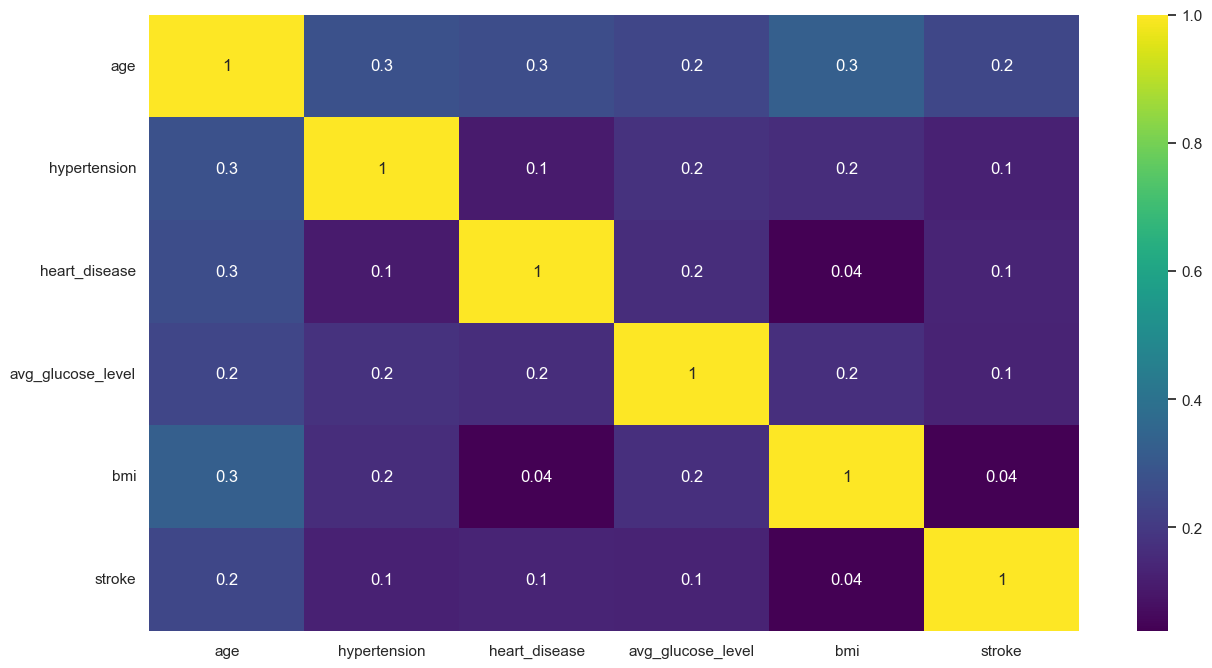

In [17]:
plt.figure(figsize=(15,8))
sns.set_theme(style="white")
heatmap=sns.heatmap(stroke.corr(), annot=True, cmap="viridis", fmt=".1g")

- Based on the heatmap, hypertension, heart disease and glucose level are highly correlated with stroke and may be the most common causes of stroke

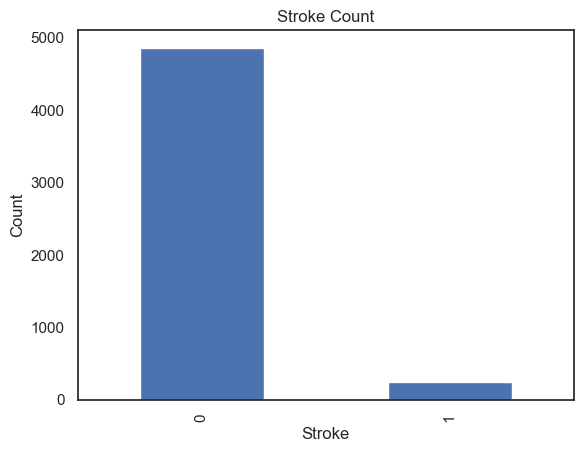

In [18]:
stroke['stroke'].value_counts().plot(kind='bar')
plt.title('Stroke Count')
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.show()

- According to the histogram of stroke count, there are approximately 95.13% people who does not have stroke and 4.87% people who have stroke 

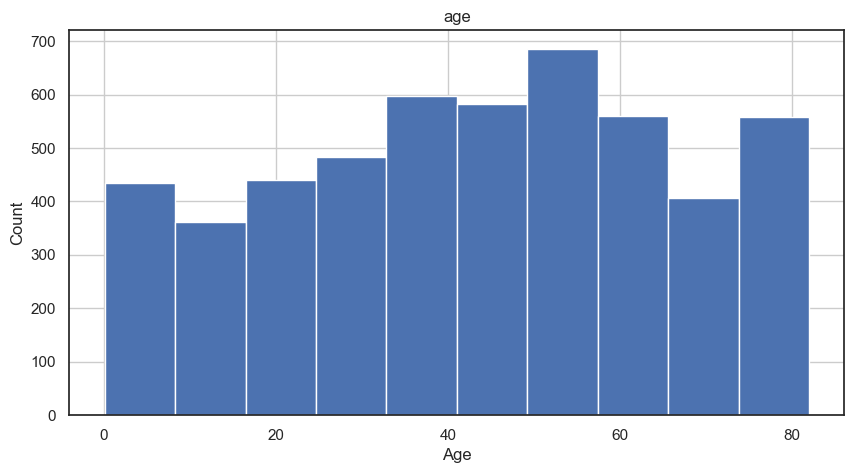

In [19]:
stroke[['age']].hist(bins=10, figsize=(10,5))
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

- People who aged around 35 to 65 have a higher chance of getting stroke

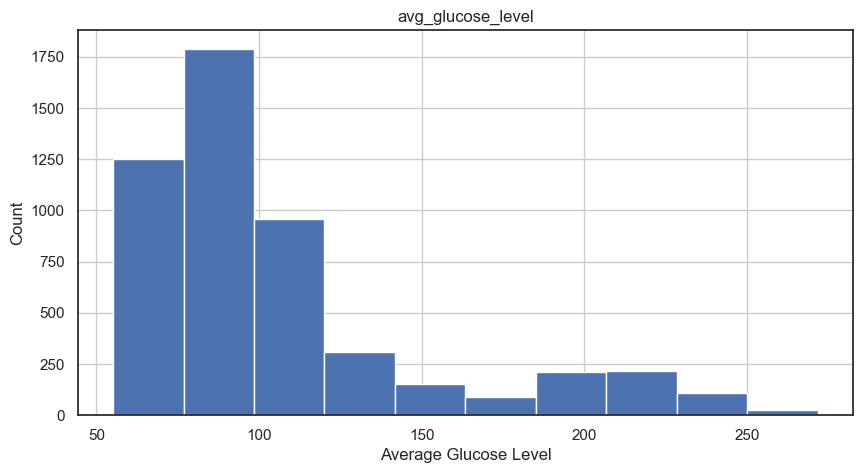

In [20]:
stroke[['avg_glucose_level']].hist(bins=10, figsize=(10,5))
plt.xlabel('Average Glucose Level')
plt.ylabel('Count')
plt.show()

- As the gluscose level increases, the number of people getting stroke decreases except the data between 50 to 100 which have a sudden increases.

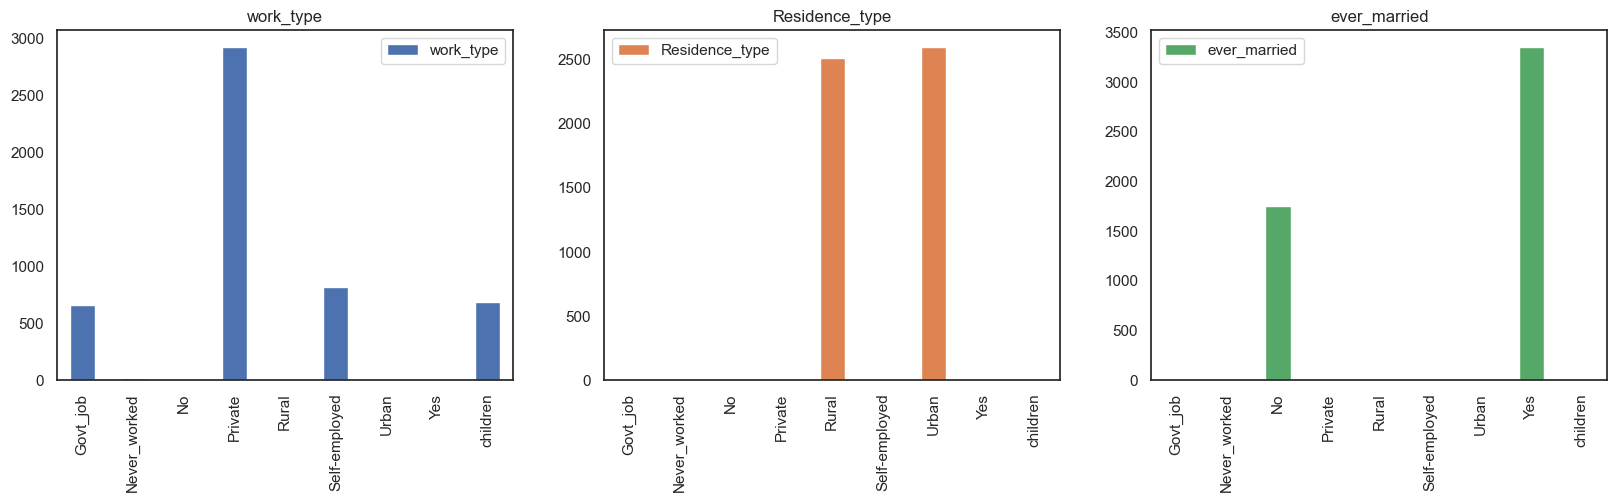

In [21]:
stroke[['work_type','Residence_type','ever_married']].apply(lambda x: x.value_counts()).plot(kind='bar', subplots=True, layout=(2,3), figsize=(20, 10))
plt.show()

- According to the graph work type, residence type and ever married, we make a assumption that stress level could also be the causes of getting stroke.

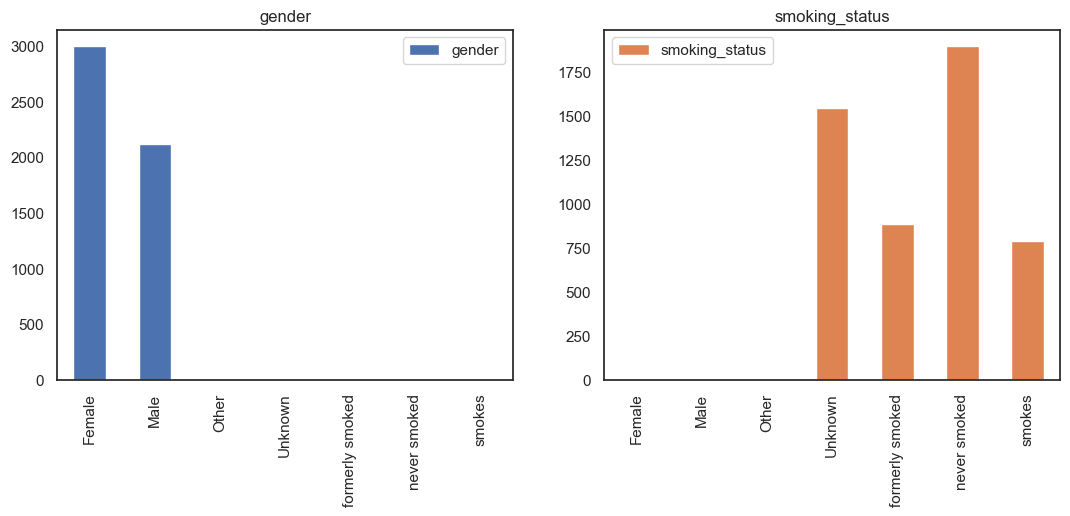

In [22]:
stroke[['gender', 'smoking_status']].apply(lambda x: x.value_counts()).plot(kind='bar', subplots=True, layout=(2,3), figsize=(20, 10))
plt.show()

# Train test split

In [23]:
X=stroke.drop(['stroke', 'gender', 'work_type', 'Residence_type', 'ever_married', 'smoking_status'],axis=1)
Y=stroke['stroke']

In [24]:
X

,age,hypertension,heart_disease,avg_glucose_level,bmi
0,67.0,0,1,228.69,36.600000
1,61.0,0,0,202.21,28.893237
2,80.0,0,1,105.92,32.500000
3,49.0,0,0,171.23,34.400000
4,79.0,1,0,174.12,24.000000
...,...,...,...,...,...
5105,80.0,1,0,83.75,28.893237
5106,81.0,0,0,125.20,40.000000
5107,35.0,0,0,82.99,30.600000
5108,51.0,0,0,166.29,25.600000


In [25]:
Y

0       1
1       1
2       1
3       1
4       1
       ..
5105    0
5106    0
5107    0
5108    0
5109    0
Name: stroke, Length: 5110, dtype: int64

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test=train_test_split(X,Y,test_size=0.2,random_state=10)

In [27]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

knn_model = knn.fit(X_train,Y_train)
Y_pred = knn.predict(X_test)

# Classification

- K-NN

In [28]:
from sklearn.metrics import accuracy_score
print(accuracy_score(Y_test,Y_pred))

0.9354207436399217


In [29]:
from sklearn.metrics import confusion_matrix
cmatrix = confusion_matrix(Y_test,Y_pred)
cmatrix

array([[956,   4],
       [ 62,   0]], dtype=int64)

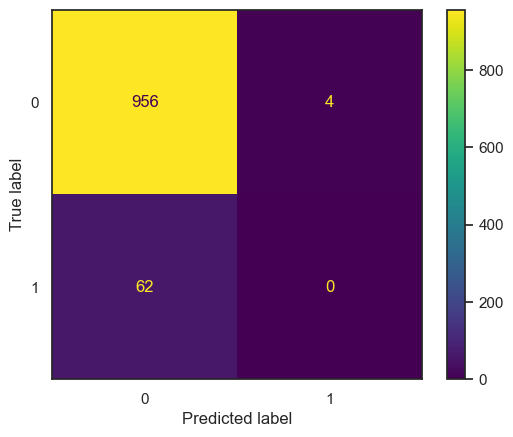

In [31]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
disp=ConfusionMatrixDisplay(confusion_matrix=cmatrix)
disp.plot()
plt.show()

- SVM

In [32]:
from sklearn.svm import SVC
svc = SVC()
svc_model = svc.fit(X_train,Y_train)
Y_pred2 = svc.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score
print(accuracy_score(Y_test,Y_pred2))

0.9393346379647749


In [34]:
from sklearn.metrics import confusion_matrix
cmatrix2 = confusion_matrix(Y_test,Y_pred2)
cmatrix2

array([[960,   0],
       [ 62,   0]], dtype=int64)

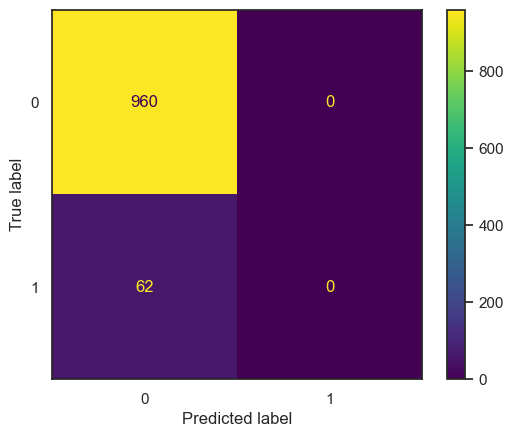

In [35]:
disp=ConfusionMatrixDisplay(confusion_matrix=cmatrix2)
disp.plot()
plt.show()

- Decision Tree

In [36]:
from sklearn.tree import DecisionTreeClassifier
DecisionTree = DecisionTreeClassifier()
DecisionTree_model = DecisionTree.fit(X_train,Y_train)
Y_pred3 = DecisionTree.predict(X_test)

In [37]:
from sklearn.metrics import accuracy_score
print(accuracy_score(Y_test,Y_pred3))

0.8933463796477495


In [38]:
from sklearn.metrics import confusion_matrix
cm3 = confusion_matrix(Y_test,Y_pred3)
cm3

array([[910,  50],
       [ 59,   3]], dtype=int64)

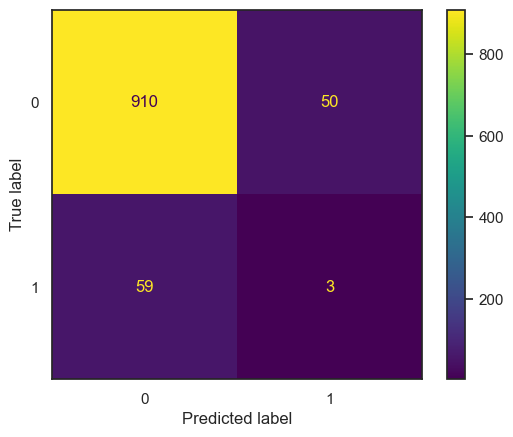

In [39]:
disp=ConfusionMatrixDisplay(confusion_matrix=cm3)
disp.plot()
plt.show()

In [40]:
from sklearn.ensemble import RandomForestClassifier
RandomForest = RandomForestClassifier()
RandomForest_model = RandomForest.fit(X_train,Y_train)
Y_pred4 = RandomForest.predict(X_test)

In [41]:
from sklearn.metrics import accuracy_score
print(accuracy_score(Y_test,Y_pred4))

0.9344422700587084


In [42]:
from sklearn.metrics import confusion_matrix
cm4 = confusion_matrix(Y_test,Y_pred4)
cm4

array([[955,   5],
       [ 62,   0]], dtype=int64)

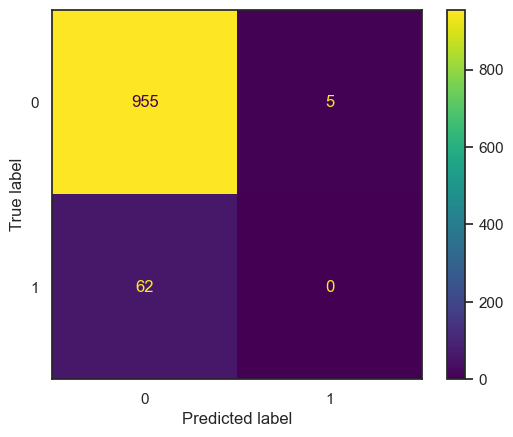

In [43]:
disp=ConfusionMatrixDisplay(confusion_matrix=cm4)
disp.plot()
plt.show()

From the outcomes of the model above, K-Nearest Neighbor(K-NN) and Random Forest classifier give us 93.5% accurate model for predicting stroke.

# Discussion and Result

From the stroke dataset we obtain from https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset , The dataset issue is "How to predict stroke with only age, hypertension, heart disease, average glucose level and body mass index? ".We try predicting a stroke category by labeled data, so we apply Supervised Learning and it is Classification.

We applied the K-Nearest Neighbor (K-NN), Support Vector Machine (SVM), Decision Tree, and Random Forest algorithms for classification. However, the accuracy of predicting value of the model that we were produced using SVM and Decision Tree is not very accurate, being 93.9% and 89.7%, respectively. Fortunately, the models that K-NN and Random Forest help us construct are 93.5% correct at predicting the type of stroke. In order to forecast stroke type, our K-Nearest Neighbor Classifier and Random Forest Classifier are the best models.